# YOLO Demo — Visual Recognition Pipeline Check

Proves the full stack works on this machine: PyTorch + CUDA on the RTX 5060 Ti,
Ultralytics YOLO inference, and a short GPU training run.

Run all cells (`Run → Run All Cells`). First run downloads small files:
the YOLO11n weights (~5 MB), a sample image, and the COCO8 toy dataset (~1 MB).

In [1]:
import torch
from ultralytics import YOLO

assert torch.cuda.is_available(), "CUDA not available — check the environment"
print(f"Running on: {torch.cuda.get_device_name(0)}")

Running on: NVIDIA GeForce RTX 5060 Ti


## 1. Inference — detect objects in an image

YOLO11n is the smallest pretrained model (80 COCO classes: person, car, dog, ...).
Swap the URL for any image path on disk to try your own.

In [2]:
model = YOLO("yolo11n.pt")  # auto-downloads on first use

results = model("https://ultralytics.com/images/bus.jpg", device=0)

for box in results[0].boxes:
    cls_name = model.names[int(box.cls)]
    print(f"{cls_name:12s} confidence={float(box.conf):.2f}")

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


image 1/1 C:\CAPSTONE\notebooks\bus.jpg: 640x480 4 persons, 1 bus, 25.1ms


Speed: 1.4ms preprocess, 25.1ms inference, 15.9ms postprocess per image at shape (1, 3, 640, 480)


bus          confidence=0.94
person       confidence=0.89
person       confidence=0.88
person       confidence=0.86
person       confidence=0.62


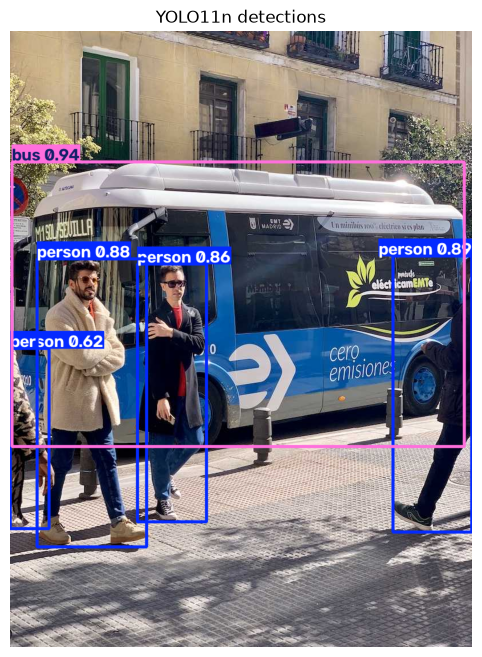

In [3]:
import matplotlib.pyplot as plt

annotated = results[0].plot()  # BGR image with boxes drawn
plt.figure(figsize=(8, 8))
plt.imshow(annotated[..., ::-1])  # BGR -> RGB
plt.axis("off")
plt.title("YOLO11n detections")
plt.show()

## 2. Training — fine-tune on the GPU

A 3-epoch run on COCO8 (a tiny 8-image dataset) just to prove training works.
Real training uses your own dataset in the same YAML format and more epochs.

With 8 GB VRAM: `imgsz=640` with `batch=8`–`16` is a comfortable starting point.

In [4]:
from pathlib import Path

train_results = model.train(
    data="coco8.yaml",  # toy dataset, auto-downloads
    epochs=3,
    imgsz=640,
    batch=8,
    device=0,
    project=str(Path.cwd().parent / "runs"),  # absolute path — Ultralytics mangles relative ones
    name="demo",
    exist_ok=True,
)
print(f"\nBest weights saved to: {train_results.save_dir}")

Ultralytics 8.4.92  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 8151MiB)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=demo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\CAPS


                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                


...

              umbrella          1          1          0          0          0          0


          potted plant          1          1          0          0          0          0


Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 1.1ms postprocess per image


Results saved to C:\CAPSTONE\runs\demo



Best weights saved to: C:\CAPSTONE\runs\demo


## Next steps

- **Your own data**: label images (e.g. with [Roboflow](https://roboflow.com) or
  [Label Studio](https://labelstud.io)), export in YOLO format, point `data=` at your YAML.
- **Webcam demo**: `model.predict(source=0, show=True)` runs live detection.
- **Other tasks**: Ultralytics also supports classification (`yolo11n-cls.pt`),
  segmentation (`yolo11n-seg.pt`), and pose estimation (`yolo11n-pose.pt`).
- Training outputs (curves, confusion matrix, sample batches) are in `../runs/demo/`.